# Reto I — Engañando a SHAP

**Objetivo:** construir y auditar un clasificador de aprobación de crédito que discrimina en producción usando `grupo_demografico`, pero que cambia su comportamiento cuando detecta perturbaciones generadas por SHAP.

La estructura sigue el notebook de clase de ataques adversariales a explicadores post hoc:

1. Preparación de datos.
2. Modelo base.
3. Validación de sesgo.
4. SHAP del modelo base.
5. Modelos `f` y `ψ`.
6. Clasificador scaffold/adversario.
7. Auditoría con KernelSHAP.
8. Comparación final.

> Nota: este notebook está diseñado para ejecutarse en Google Colab.

## Diagrama del ataque — Clasificador scaffold

```mermaid
flowchart TD
    USER["Dato real de producción<br/>solicitud de crédito"]
    SHAP["KernelSHAP<br/>perturbaciones por enmascaramiento"]
    OOD{"Detector OOD<br/>dependencias rotas"}
    F["Modelo sesgado f<br/>usa grupo_demografico"]
    PSI["Modelo inocuo ψ<br/>usa incumplimiento_previo + variables objetivas"]
    R1["Predicción discriminatoria<br/>en producción"]
    R2["Explicación aparentemente objetiva<br/>durante auditoría SHAP"]

    USER -->|dato real| OOD
    SHAP -.->|muestras perturbadas| OOD
    OOD -->|In-distribution| F
    OOD -->|Out-of-distribution| PSI
    F --> R1
    PSI -.-> R2
```

La idea central es que SHAP perturba datos reemplazando columnas. Eso puede romper dependencias reales entre variables. El clasificador adversario aprovecha ese patrón para detectar la auditoría y cambiar su comportamiento.

In [30]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SEED = 42
np.random.seed(SEED)

# SHAP puede no venir instalado en Colab.
try:
    import shap
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

## 2. Funciones utilitarias

Estas funciones evitan repetir código y dejan el notebook más parecido al ejemplo de clase.

In [32]:
# ==========================================
# 2. FUNCIONES UTILITARIAS
# ==========================================

def find_csv_path():
    """
    Busca el CSV del reto en rutas comunes de Colab/local.
    Ajusta manualmente DATA_PATH si tu archivo está en otra ubicación.
    """
    candidates = [
        "../data/input/aprobacion_de_credito_modificada.csv",
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        "No encontré aprobacion_de_credito_modificada.csv. "
        "Sube el archivo a Colab o ajusta DATA_PATH manualmente."
    )


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def minmax_scale(series, ref_series):
    """
    Normaliza una serie usando el mínimo y máximo del conjunto de referencia.
    """
    denom = ref_series.max() - ref_series.min()
    if denom == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - ref_series.min()) / denom


def build_shap_importance_table(shap_values, X_reference, feature_col="feature"):
    """
    Devuelve mean(|SHAP|) por variable.
    Soporta salidas SHAP como lista, matriz 2D o tensor 3D.
    """
    values = shap_values[1] if isinstance(shap_values, list) else shap_values
    values = np.array(values)

    if values.ndim == 3:
        values = values[:, :, 1]

    return (
        pd.DataFrame({
            feature_col: X_reference.columns,
            "mean_abs_shap": np.abs(values).mean(axis=0)
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )


def plot_group_approval(table, group_col="grupo", rate_col="aprobacion_predicha_pct", title="Tasa de aprobación por grupo"):
    plt.figure(figsize=(7, 4))
    plt.bar(table[group_col], table[rate_col])
    plt.title(title)
    plt.ylabel("Tasa de aprobación (%)")
    plt.xlabel("Grupo demográfico")
    plt.ylim(0, 100)
    for i, value in enumerate(table[rate_col]):
        plt.text(i, value + 2, f"{value:.2f}%", ha="center")
    plt.show()


def fairness_by_group(X_data, y_true, y_pred, y_proba, group_labels):
    """
    Calcula tasas de aprobación reales/predichas por grupo y métricas simples de fairness.
    """
    results = X_data.copy()
    results["y_real"] = np.array(y_true)
    results["y_pred"] = np.array(y_pred)
    results["y_proba"] = np.array(y_proba)
    results["grupo"] = results["grupo_demografico"].map(group_labels)

    table = (
        results
        .groupby(["grupo_demografico", "grupo"])
        .agg(
            solicitudes=("y_real", "count"),
            aprobacion_real=("y_real", "mean"),
            aprobacion_predicha=("y_pred", "mean"),
            probabilidad_promedio=("y_proba", "mean")
        )
        .reset_index()
    )

    table["aprobacion_real_pct"] = table["aprobacion_real"] * 100
    table["aprobacion_predicha_pct"] = table["aprobacion_predicha"] * 100
    table["probabilidad_promedio_pct"] = table["probabilidad_promedio"] * 100

    aprob_indigena = table.loc[table["grupo_demografico"] == 0, "aprobacion_predicha"].iloc[0]
    aprob_general = table.loc[table["grupo_demografico"] == 1, "aprobacion_predicha"].iloc[0]

    demographic_parity_difference = aprob_general - aprob_indigena
    disparate_impact = aprob_indigena / aprob_general if aprob_general != 0 else np.nan

    metrics = {
        "demographic_parity_difference": demographic_parity_difference,
        "disparate_impact": disparate_impact
    }

    return table, metrics

## 3. Carga y validación del dataset

Variables clave del reto:

- `grupo_demografico`: 0 = indígena, 1 = población general.
- `incumplimiento_previo`: variable aparentemente objetiva de riesgo crediticio.
- `aprobado`: variable objetivo.

In [33]:
# ==========================================
# 3. CARGA Y VALIDACIÓN DEL DATASET
# ==========================================

DATA_PATH = find_csv_path()
df = pd.read_csv(DATA_PATH)

grupo_labels = {
    0: "Indígena",
    1: "Población general"
}

print("Ruta usada:", DATA_PATH)
print("Dimensiones:", df.shape)

display(df.head())
display(df.isna().sum().to_frame("nulos"))

required_columns = [
    "edad", "ingreso", "deuda", "antiguedad_laboral", "linea_credito",
    "codigo_postal", "genero", "estado_civil", "tipo_cliente", "educacion",
    "ocupacion", "incumplimiento_previo", "empleado", "licencia",
    "ciudadania", "grupo_demografico", "aprobado"
]

missing = sorted(set(required_columns) - set(df.columns))
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

df = df[required_columns].copy()

Ruta usada: ../data/input/aprobacion_de_credito_modificada.csv
Dimensiones: (653, 17)


,genero,edad,deuda,estado_civil,tipo_cliente,educacion,ocupacion,antiguedad_laboral,incumplimiento_previo,empleado,linea_credito,licencia,ciudadania,codigo_postal,ingreso,aprobado,grupo_demografico
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1,0,0,202.0,0,1,1
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6,0,0,43.0,560,1,0
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0,0,0,280.0,824,1,1
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5,1,0,100.0,3,1,1
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0,0,2,120.0,0,1,1


,nulos
genero,0
edad,0
deuda,0
estado_civil,0
tipo_cliente,0
educacion,0
ocupacion,0
antiguedad_laboral,0
incumplimiento_previo,0
empleado,0


,grupo_demografico,grupo,solicitudes,aprobados,tasa_aprobacion_pct
0,0,Indígena,356,27,7.584270
1,1,Población general,297,269,90.572391


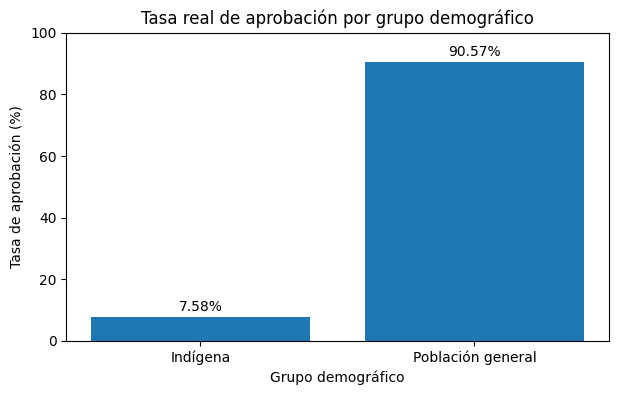

In [34]:
# ==========================================
# 3.1 SESGO PRESENTE EN LA DATA CRUDA
# ==========================================

raw_approval = (
    df.groupby("grupo_demografico")["aprobado"]
    .agg(solicitudes="count", aprobados="sum", tasa_aprobacion="mean")
    .reset_index()
)
raw_approval["grupo"] = raw_approval["grupo_demografico"].map(grupo_labels)
raw_approval["tasa_aprobacion_pct"] = raw_approval["tasa_aprobacion"] * 100

display(raw_approval[["grupo_demografico", "grupo", "solicitudes", "aprobados", "tasa_aprobacion_pct"]])

plt.figure(figsize=(7, 4))
plt.bar(raw_approval["grupo"], raw_approval["tasa_aprobacion_pct"])
plt.title("Tasa real de aprobación por grupo demográfico")
plt.ylabel("Tasa de aprobación (%)")
plt.xlabel("Grupo demográfico")
plt.ylim(0, 100)
for i, value in enumerate(raw_approval["tasa_aprobacion_pct"]):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")
plt.show()

## 4. Modelo base

Primero entrenamos un clasificador normal que usa todas las variables, incluyendo `grupo_demografico`, para predecir `aprobado`.

Este bloque cubre la primera instrucción del reto.

In [35]:
# ==========================================
# 4. MODELO BASE
# ==========================================

X = df.drop(columns=["aprobado"])
y = df["aprobado"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=SEED,
    class_weight="balanced"
)

base_model.fit(X_train, y_train)

y_pred = base_model.predict(X_test)
y_proba = base_model.predict_proba(X_test)[:, 1]

metricas_base = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)
print("\nMétricas del modelo base:")
for metric, value in metricas_base.items():
    print(f"{metric}: {value:.4f}")

print("\nMatriz de confusión:")
display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Real: Rechazado", "Real: Aprobado"],
    columns=["Pred: Rechazado", "Pred: Aprobado"]
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Tamaño de entrenamiento: (489, 16)
Tamaño de prueba: (164, 16)

Métricas del modelo base:
accuracy: 0.9634
precision: 0.9722
recall: 0.9459
f1: 0.9589
roc_auc: 0.9913

Matriz de confusión:


,Pred: Rechazado,Pred: Aprobado
Real: Rechazado,88,2
Real: Aprobado,4,70



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        90
           1       0.97      0.95      0.96        74

    accuracy                           0.96       164
   macro avg       0.96      0.96      0.96       164
weighted avg       0.96      0.96      0.96       164



## 5. Validación cuantitativa del sesgo

Aquí se cubre la segunda instrucción del reto:

- Tasas de aprobación por grupo.
- Diferencia de paridad demográfica.
- Disparate impact.
- Importancia de `grupo_demografico` dentro del modelo.

,grupo_demografico,grupo,solicitudes,aprobacion_real,aprobacion_predicha,probabilidad_promedio,aprobacion_real_pct,aprobacion_predicha_pct,probabilidad_promedio_pct
0,0,Indígena,91,0.065934,0.032967,0.122599,6.593407,3.296703,12.259898
1,1,Población general,73,0.931507,0.945205,0.880174,93.150685,94.520548,88.017432


Métricas de fairness del modelo base:
Demographic Parity Difference: 0.9122
Disparate Impact: 0.0349


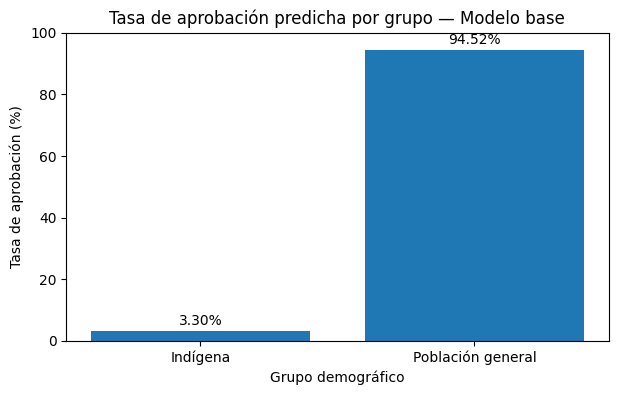

,feature,importance
0,grupo_demografico,0.384708
1,incumplimiento_previo,0.258338
2,linea_credito,0.071683
3,ingreso,0.056851
4,empleado,0.049626
5,antiguedad_laboral,0.046198
6,deuda,0.028433
7,codigo_postal,0.025906
8,edad,0.024577
9,educacion,0.020666


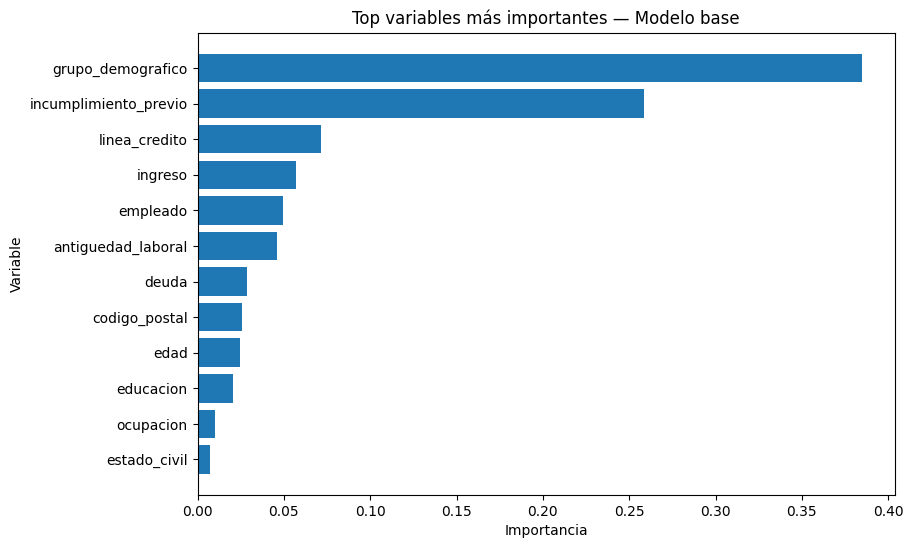

In [36]:
# ==========================================
# 5. FAIRNESS DEL MODELO BASE
# ==========================================

fairness_table, fairness_metrics = fairness_by_group(
    X_data=X_test,
    y_true=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    group_labels=grupo_labels
)

display(fairness_table)

print("Métricas de fairness del modelo base:")
print(f"Demographic Parity Difference: {fairness_metrics['demographic_parity_difference']:.4f}")
print(f"Disparate Impact: {fairness_metrics['disparate_impact']:.4f}")

plot_group_approval(
    fairness_table,
    rate_col="aprobacion_predicha_pct",
    title="Tasa de aprobación predicha por grupo — Modelo base"
)

feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": base_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance["feature"].head(12)[::-1],
    feature_importance["importance"].head(12)[::-1]
)
plt.title("Top variables más importantes — Modelo base")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## 6. SHAP del modelo base

Antes del ataque, SHAP debe reflejar el comportamiento real del modelo base. Esto sirve como línea base para comparar contra el clasificador adversario.

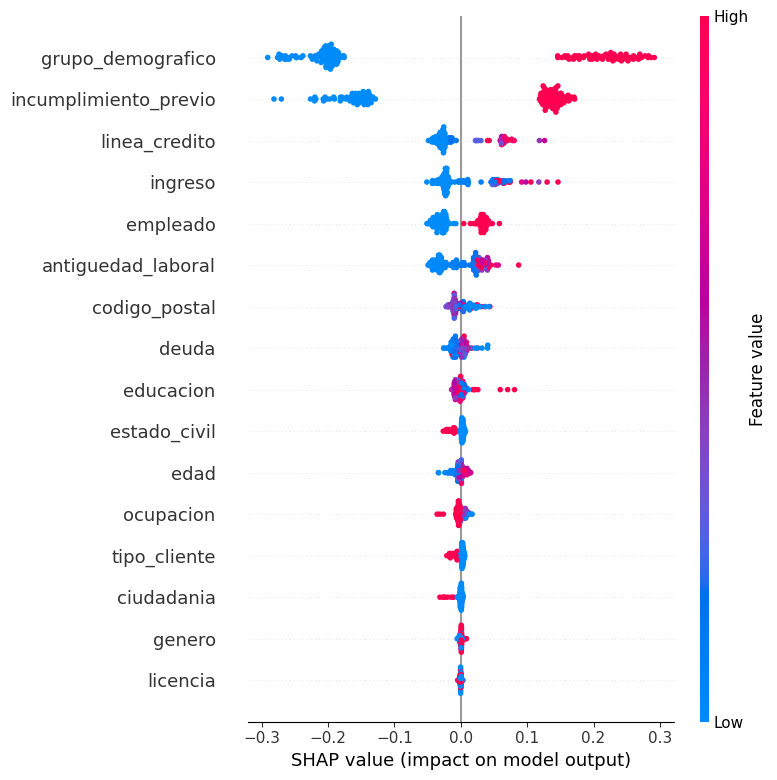

,feature,mean_abs_shap
0,grupo_demografico,0.215008
1,incumplimiento_previo,0.151585
2,linea_credito,0.035553
3,ingreso,0.033913
4,empleado,0.031553
5,antiguedad_laboral,0.028832
6,codigo_postal,0.011263
7,deuda,0.008416
8,educacion,0.006091
9,estado_civil,0.005620


In [37]:
# ==========================================
# 6. SHAP DEL MODELO BASE
# ==========================================

X_test_shap = X_test.copy()

explainer_base = shap.TreeExplainer(base_model)
shap_values_base = explainer_base.shap_values(X_test_shap)

if isinstance(shap_values_base, list):
    shap_values_base_class_1 = shap_values_base[1]
else:
    shap_values_base_class_1 = np.array(shap_values_base)
    if shap_values_base_class_1.ndim == 3:
        shap_values_base_class_1 = shap_values_base_class_1[:, :, 1]

shap.summary_plot(
    shap_values_base_class_1,
    X_test_shap,
    feature_names=X_test_shap.columns,
    show=True
)

shap_importance_base = build_shap_importance_table(
    shap_values_base_class_1,
    X_test_shap
)

display(shap_importance_base)

## 7. Definición de modelos $f$ y $\psi$

Como en el ejemplo de clase, separamos explícitamente dos comportamientos:

### Modelo sesgado $f$
Usa `grupo_demografico` de forma determinante:

- Población general (`grupo_demografico = 1`) → mayor probabilidad de aprobación.
- Grupo indígena (`grupo_demografico = 0`) → menor probabilidad de aprobación.

### Modelo inocuo $\psi$
Usa una lógica aparentemente objetiva:

- `incumplimiento_previo`.
- `ingreso`.
- `deuda`.
- `linea_credito`.
- `antiguedad_laboral`.
- `empleado`.

Este será el comportamiento que SHAP observará cuando el detector marque perturbaciones OOD.

In [38]:
# ==========================================
# 7. MODELOS f (SESGADO) Y psi (INOCUO)
# ==========================================

class BiasedCreditModelF:
    """
    Modelo sesgado f:
    En producción usa grupo_demografico de forma determinante.
    """

    def __init__(self, grupo_col="grupo_demografico"):
        self.grupo_col = grupo_col

    def predict_proba(self, X):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=X_train.columns)

        proba_aprobado = np.where(
            X_df[self.grupo_col] == 1,
            0.95,
            0.05
        )

        return np.column_stack([1 - proba_aprobado, proba_aprobado])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


class InnocuousCreditModelPsi:
    """
    Modelo inocuo psi:
    Aparenta decidir con variables objetivas, principalmente incumplimiento_previo.
    """

    def __init__(self, reference_data):
        self.reference_data = reference_data.copy()

    def predict_proba(self, X):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=X_train.columns)
        X_df = X_df.copy()

        ingreso_norm = minmax_scale(X_df["ingreso"], self.reference_data["ingreso"])
        deuda_norm = minmax_scale(X_df["deuda"], self.reference_data["deuda"])
        linea_norm = minmax_scale(X_df["linea_credito"], self.reference_data["linea_credito"])
        antiguedad_norm = minmax_scale(X_df["antiguedad_laboral"], self.reference_data["antiguedad_laboral"])

        score = (
            2.8 * (1 - X_df["incumplimiento_previo"]) +
            0.45 * ingreso_norm +
            0.35 * linea_norm +
            0.30 * antiguedad_norm +
            0.20 * X_df["empleado"] -
            0.45 * deuda_norm -
            1.4
        )

        proba_aprobado = sigmoid(score)

        return np.column_stack([1 - proba_aprobado, proba_aprobado])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


biased_model_f = BiasedCreditModelF()
innocuous_model_psi = InnocuousCreditModelPsi(reference_data=X_train)

print("Predicciones f para 5 instancias:", biased_model_f.predict(X_test.head()))
print("Predicciones psi para 5 instancias:", innocuous_model_psi.predict(X_test.head()))

Predicciones f para 5 instancias: [1 1 0 0 1]
Predicciones psi para 5 instancias: [0 0 1 1 0]


## 8. Clasificador scaffold / adversario

El clasificador adversario enruta cada instancia:

- Si parece dato real → usa $f$.
- Si parece perturbación de SHAP → usa $\psi$.

El detector OOD combina:

1. `IsolationForest`, entrenado con datos reales.
2. Una regla de dependencia rota entre `grupo_demografico` e `incumplimiento_previo`.

In [39]:
# ==========================================
# 8. DETECTOR OOD
# ==========================================

ood_detector = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("isolation_forest", IsolationForest(
        n_estimators=300,
        contamination=0.08,
        random_state=SEED
    ))
])

ood_detector.fit(X_train)

ood_train = ood_detector.predict(X_train)
ood_test = ood_detector.predict(X_test)

print("Distribución OOD en train:")
display(pd.Series(ood_train).value_counts().rename(index={1: "Normal", -1: "OOD"}))

print("\nDistribución OOD en test:")
display(pd.Series(ood_test).value_counts().rename(index={1: "Normal", -1: "OOD"}))

Distribución OOD en train:


Normal    449
OOD        40
Name: count, dtype: int64


Distribución OOD en test:


Normal    145
OOD        19
Name: count, dtype: int64

In [40]:
# ==========================================
# 8.1 CLASIFICADOR SCAFFOLD ADVERSARIO
# ==========================================

class AdversarialCreditScaffold:
    """
    Scaffold adversario:
    - In-distribution  -> modelo sesgado f.
    - Out-of-distribution -> modelo inocuo psi.
    """

    def __init__(
        self,
        biased_model,
        innocuous_model,
        ood_detector,
        feature_names,
        grupo_col="grupo_demografico",
        incumplimiento_col="incumplimiento_previo"
    ):
        self.biased_model = biased_model
        self.innocuous_model = innocuous_model
        self.ood_detector = ood_detector
        self.feature_names = list(feature_names)
        self.grupo_col = grupo_col
        self.incumplimiento_col = incumplimiento_col

    def _ensure_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X[self.feature_names].copy()
        return pd.DataFrame(X, columns=self.feature_names)

    def _detect_ood(self, X_df):
        iso_flags = self.ood_detector.predict(X_df)

        # Regla adversaria:
        # Si SHAP reemplaza columnas marginalmente, puede crear combinaciones
        # donde la relación real entre grupo_demografico e incumplimiento_previo se rompe.
        dependencia_rota = (
            ((X_df[self.grupo_col] == 1) & (X_df[self.incumplimiento_col] == 1)) |
            ((X_df[self.grupo_col] == 0) & (X_df[self.incumplimiento_col] == 0))
        )

        return np.where((iso_flags == -1) | dependencia_rota, -1, 1)

    def predict_proba(self, X):
        X_df = self._ensure_dataframe(X)
        ood_flags = self._detect_ood(X_df)

        proba = np.zeros((len(X_df), 2))

        normal_mask = ood_flags == 1
        ood_mask = ood_flags == -1

        if normal_mask.any():
            proba[normal_mask] = self.biased_model.predict_proba(X_df.loc[normal_mask])

        if ood_mask.any():
            proba[ood_mask] = self.innocuous_model.predict_proba(X_df.loc[ood_mask])

        return proba

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


adversarial_model = AdversarialCreditScaffold(
    biased_model=biased_model_f,
    innocuous_model=innocuous_model_psi,
    ood_detector=ood_detector,
    feature_names=X_train.columns
)

adv_y_pred = adversarial_model.predict(X_test)
adv_y_proba = adversarial_model.predict_proba(X_test)[:, 1]

display(pd.DataFrame({
    "grupo_demografico": X_test["grupo_demografico"].values[:10],
    "incumplimiento_previo": X_test["incumplimiento_previo"].values[:10],
    "proba_aprobado": adv_y_proba[:10],
    "prediccion": adv_y_pred[:10]
}))

,grupo_demografico,incumplimiento_previo,proba_aprobado,prediccion
0,1,1,0.238833,0
1,1,1,0.226021,0
2,0,0,0.778310,1
3,0,0,0.802184,1
4,1,1,0.236038,0
5,1,1,0.181301,0
6,1,1,0.223258,0
7,1,1,0.196342,0
8,0,0,0.801830,1
9,0,0,0.798067,1


## 9. Validación del sesgo del clasificador adversario

Antes de auditar con SHAP, se verifica que el modelo adversario sí discrimina en datos reales.

,grupo_demografico,grupo,solicitudes,aprobacion_real,aprobacion_predicha,probabilidad_promedio,aprobacion_real_pct,aprobacion_predicha_pct,probabilidad_promedio_pct
0,0,Indígena,91,0.065934,0.758242,0.622322,6.593407,75.824176,62.232159
1,1,Población general,73,0.931507,0.054795,0.257163,93.150685,5.479452,25.716310


Métricas de fairness del modelo adversario:
Demographic Parity Difference: -0.7034
Disparate Impact: 13.8379


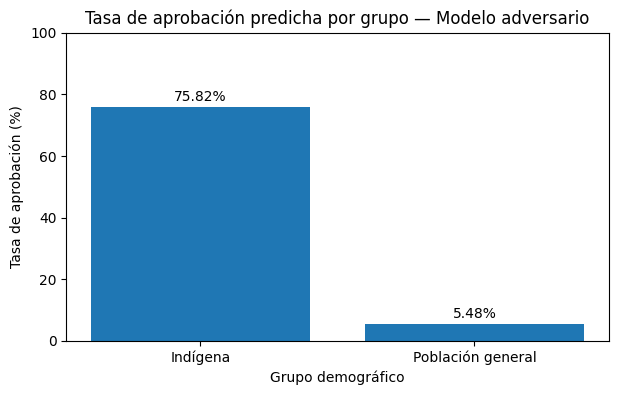

In [41]:
# ==========================================
# 9. FAIRNESS DEL MODELO ADVERSARIO EN DATOS REALES
# ==========================================

adv_fairness, adv_fairness_metrics = fairness_by_group(
    X_data=X_test,
    y_true=y_test,
    y_pred=adv_y_pred,
    y_proba=adv_y_proba,
    group_labels=grupo_labels
)

display(adv_fairness)

print("Métricas de fairness del modelo adversario:")
print(f"Demographic Parity Difference: {adv_fairness_metrics['demographic_parity_difference']:.4f}")
print(f"Disparate Impact: {adv_fairness_metrics['disparate_impact']:.4f}")

plot_group_approval(
    adv_fairness,
    rate_col="aprobacion_predicha_pct",
    title="Tasa de aprobación predicha por grupo — Modelo adversario"
)

## 10. Ataque adversarial contra KernelSHAP

KernelSHAP consultará el clasificador con datos perturbados. El detector OOD debe enviar esas perturbaciones al modelo inocuo $\psi$.

El éxito del ataque se observa si SHAP coloca a `incumplimiento_previo` como variable dominante y reduce la visibilidad de `grupo_demografico`.

In [42]:
# ==========================================
# 10. KERNELSHAP SOBRE EL CLASIFICADOR ADVERSARIO
# ==========================================

def adversarial_predict_for_shap(X):
    """
    Función compatible con KernelSHAP.
    Regresa P(aprobado = 1).
    """
    return adversarial_model.predict_proba(X)[:, 1]


background = shap.sample(X_train, 50, random_state=SEED)
X_explain = shap.sample(X_test, 80, random_state=SEED)

print("Background:", background.shape)
print("Muestra a explicar:", X_explain.shape)

explainer_adv = shap.KernelExplainer(
    adversarial_predict_for_shap,
    background
)

shap_values_adv = explainer_adv.shap_values(
    X_explain,
    nsamples=300
)

print("SHAP values calculados.")
print("Shape:", np.array(shap_values_adv).shape)

Background: (50, 16)
Muestra a explicar: (80, 16)


100%|██████████| 80/80 [00:06<00:00, 11.87it/s]

SHAP values calculados.
Shape: (80, 16)


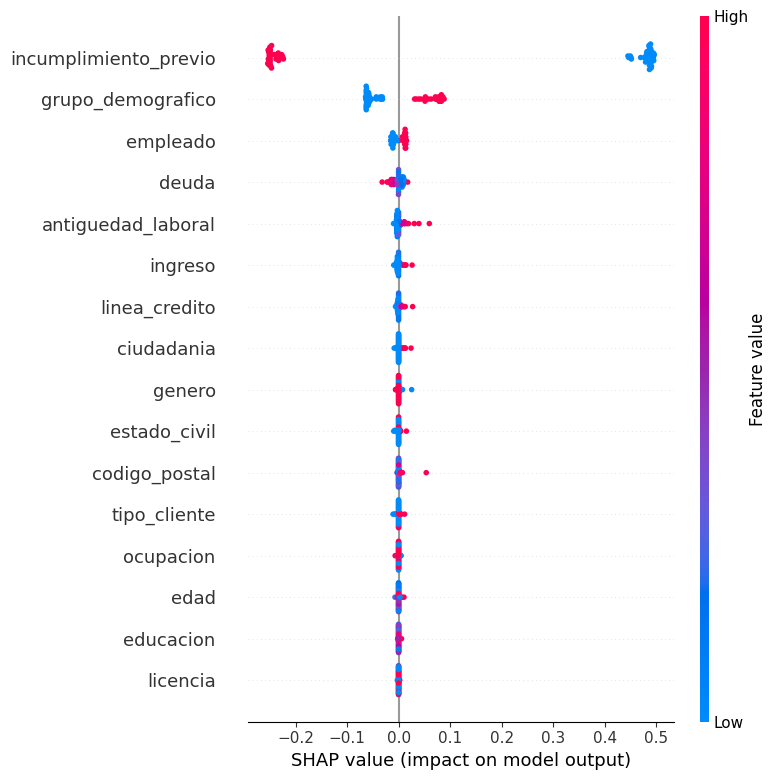

,feature,mean_abs_shap
0,incumplimiento_previo,0.359993
1,grupo_demografico,0.061818
2,empleado,0.011485
3,deuda,0.007192
4,antiguedad_laboral,0.004783
5,ingreso,0.002857
6,linea_credito,0.002279
7,ciudadania,0.001831
8,genero,0.001448
9,estado_civil,0.001335


In [43]:
# ==========================================
# 10.1 SUMMARY PLOT E IMPORTANCIA SHAP ADVERSARIA
# ==========================================

shap.summary_plot(
    shap_values_adv,
    X_explain,
    feature_names=X_explain.columns,
    show=True
)

shap_importance_adv = build_shap_importance_table(
    shap_values_adv,
    X_explain
)

display(shap_importance_adv)

In [44]:
# ==========================================
# 10.2 COMPARACIÓN DIRECTA ENTRE SHAP BASE Y SHAP ADVERSARIO
# ==========================================

comparison_shap = (
    shap_importance_base
    .rename(columns={"mean_abs_shap": "mean_abs_shap_base"})
    .merge(
        shap_importance_adv.rename(columns={"mean_abs_shap": "mean_abs_shap_adversario"}),
        on="feature",
        how="outer"
    )
    .fillna(0)
)

comparison_shap["ratio_adv_vs_base"] = (
    comparison_shap["mean_abs_shap_adversario"] /
    comparison_shap["mean_abs_shap_base"].replace(0, np.nan)
)

comparison_shap = comparison_shap.sort_values("mean_abs_shap_adversario", ascending=False)

display(comparison_shap)

,feature,mean_abs_shap_base,mean_abs_shap_adversario,ratio_adv_vs_base
10,incumplimiento_previo,0.151585,0.359993,2.374863
9,grupo_demografico,0.215008,0.061818,0.287517
6,empleado,0.031553,0.011485,0.363980
3,deuda,0.008416,0.007192,0.854559
0,antiguedad_laboral,0.028832,0.004783,0.165886
11,ingreso,0.033913,0.002857,0.084245
13,linea_credito,0.035553,0.002279,0.064096
1,ciudadania,0.001963,0.001831,0.932622
8,genero,0.001130,0.001448,1.281345
7,estado_civil,0.005620,0.001335,0.237593


## 11. Interpretación del resultado

La tabla `shap_importance_adv` resume el ataque.

La lectura esperada es:

- `incumplimiento_previo` aparece como la variable dominante durante la auditoría.
- `grupo_demografico` deja de ser la explicación principal.
- La explicación de SHAP describe el comportamiento activado ante perturbaciones, no necesariamente el comportamiento real del modelo en producción.

Si `grupo_demografico` aparece con una contribución residual, eso no invalida el ataque: lo importante es que la auditoría queda desplazada hacia una variable aparentemente objetiva.

In [45]:
# ==========================================
# 11. RESUMEN FINAL
# ==========================================

def get_rank(table, feature):
    table_reset = table.reset_index(drop=True)
    row = table_reset.query("feature == @feature")
    if row.empty:
        return np.nan
    return int(row.index[0] + 1)

summary_rows = []

for feature in ["incumplimiento_previo", "grupo_demografico"]:
    summary_rows.append({
        "feature": feature,
        "rank_shap_base": get_rank(shap_importance_base, feature),
        "mean_abs_shap_base": float(
            shap_importance_base.loc[shap_importance_base["feature"] == feature, "mean_abs_shap"].iloc[0]
        ),
        "rank_shap_adversario": get_rank(shap_importance_adv, feature),
        "mean_abs_shap_adversario": float(
            shap_importance_adv.loc[shap_importance_adv["feature"] == feature, "mean_abs_shap"].iloc[0]
        )
    })

summary_attack = pd.DataFrame(summary_rows)
display(summary_attack)

if (
    summary_attack.loc[summary_attack["feature"] == "incumplimiento_previo", "mean_abs_shap_adversario"].iloc[0]
    >
    summary_attack.loc[summary_attack["feature"] == "grupo_demografico", "mean_abs_shap_adversario"].iloc[0]
):
    print("Resultado: el ataque desplaza la explicación principal hacia incumplimiento_previo.")
else:
    print("Resultado: el ataque no fue suficiente; ajustar detector OOD o modelo psi.")

,feature,rank_shap_base,mean_abs_shap_base,rank_shap_adversario,mean_abs_shap_adversario
0,incumplimiento_previo,2,0.151585,1,0.359993
1,grupo_demografico,1,0.215008,2,0.061818


Resultado: el ataque desplaza la explicación principal hacia incumplimiento_previo.


## Conclusión

El reto muestra que SHAP no debe interpretarse como una prueba irrefutable de ausencia de discriminación.

En datos reales, el clasificador adversario mantiene una conducta discriminatoria porque enruta las observaciones normales al modelo sesgado $f$, que usa `grupo_demografico`.

Durante la auditoría, KernelSHAP genera perturbaciones que pueden romper dependencias entre variables. El detector OOD identifica esas muestras como sospechosas y activa el modelo inocuo $\psi$, el cual decide principalmente con `incumplimiento_previo` y variables objetivas de crédito.

Por eso, la explicación de SHAP puede describir el comportamiento del modelo bajo auditoría, no el comportamiento real en producción.

Una auditoría de fairness debe complementar SHAP con métricas por subgrupo, análisis contrafactual, validación sobre datos reales y pruebas específicas contra comportamiento adversarial.